## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Folder utama penyimpanan
import os
DRIVE_PATH = '/content/drive/MyDrive/Skripsi_Faris'
os.makedirs(DRIVE_PATH, exist_ok=True)
print("Google Drive berhasil di-mount. Folder:", DRIVE_PATH)

Mounted at /content/drive
Google Drive berhasil di-mount. Folder: /content/drive/MyDrive/Skripsi_Faris


## 1. Load Dataset Hasil Preprocessing

In [ ]:
import pandas as pd

STEMMING_PATH = f'{DRIVE_PATH}/7_stemming_data.csv'
data_clean = pd.read_csv(STEMMING_PATH)

print("=== HASIL LOAD DATASET ===")
print(f"Jumlah data  : {len(data_clean)}")
print(f"Kolom        : {list(data_clean.columns)}")
print()
print("Distribusi label:")
print(data_clean['Label'].value_counts())
print()
data_clean[['content', 'text_stemindo', 'Label']].head(10)

=== HASIL LOAD DATASET ===
Jumlah data  : 8364
Kolom        : ['content', 'score', 'Label', 'text_clean', 'text_StopWord', 'text_tokens', 'text_stemindo']

Distribusi label:
Label
Positif    3891
Netral     3803
Negatif     670
Name: count, dtype: int64



,content,text_stemindo,Label
0,top,top,Positif
1,sangat membantu mengubah poto jadi bagus saya ...,bantu ubah poto bagus senang,Positif
2,maksa bet dari pertama ada udah muncul terus d...,maksa bet udah muncul iklan hp ku skip dikit m...,Negatif
3,sangatsangatamat puas terimakasih dola,sangatsangatamat puas terimakasih dola,Positif
4,baik,NaN,Positif
5,hebaaat dan cerdas,hebaaat cerdas,Netral
6,jos jis broo,jos jis broo,Netral
7,bijak tapi ah bloon,bijak ah bloon,Netral
8,Dola Sejati,dola sejati,Netral
9,qa,qa,Netral


## 2. Distribusi Label Sentimen

=== DISTRIBUSI LABEL SENTIMEN ===
Label
Positif    3891
Netral     3803
Negatif     670
Name: count, dtype: int64

Total data : 8364


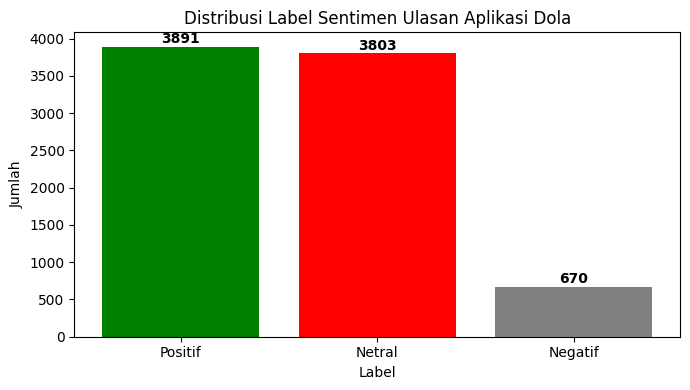

In [ ]:
import matplotlib.pyplot as plt

sentimen_count = my_df['Label'].value_counts()

print("=== DISTRIBUSI LABEL SENTIMEN ===")
print(sentimen_count)
print(f"\nTotal data : {len(my_df)}")

plt.figure(figsize=(7, 4))
bars = plt.bar(sentimen_count.index, sentimen_count.values, color=['green', 'red', 'gray'])
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.title('Distribusi Label Sentimen Ulasan Aplikasi Dola')
for bar, val in zip(bars, sentimen_count.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

data_clean = my_df.copy()
X = data_clean['text_stemindo']
y = data_clean['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== HASIL SPLITTING DATA (80:20) ===")
print(f"Total data          : {len(X)}")
print(f"Jumlah Data Train   : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Jumlah Data Test    : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print()
print("Distribusi label data train:")
print(y_train.value_counts())
print()
print("Distribusi label data test:")
print(y_test.value_counts())
print()

# Cek indikasi overfitting/underfitting
total = len(X)
n_train = len(X_train)
n_test = len(X_test)
n_features = len(set(' '.join(X_train.tolist()).split()))
ratio = n_train / n_features

print("=== ANALISIS SPLITTING ===")
print(f"Jumlah fitur (vocab size) : {n_features}")
print(f"Rasio data train/fitur    : {ratio:.4f}")
if ratio < 1:
    print("Indikasi : Berisiko UNDERFITTING — data train lebih sedikit dari jumlah fitur.")
    print("Saran    : Tambah data atau kurangi fitur (misal: batasi max_features TF-IDF).")
elif ratio < 5:
    print("Indikasi : Data train cukup namun perlu diperhatikan kompleksitas model.")
else:
    print("Indikasi : Data train cukup representatif, risiko underfitting rendah.")

=== HASIL SPLITTING DATA (80:20) ===
Total data          : 8364
Jumlah Data Train   : 6691 (80%)
Jumlah Data Test    : 1673 (20%)

Distribusi label data train:
Label
Positif    3113
Netral     3042
Negatif     536
Name: count, dtype: int64

Distribusi label data test:
Label
Positif    778
Netral     761
Negatif    134
Name: count, dtype: int64

=== ANALISIS SPLITTING ===
Jumlah fitur (vocab size) : 6307
Rasio data train/fitur    : 1.0609
Indikasi : Data train cukup namun perlu diperhatikan kompleksitas model.


In [ ]:
# Simpan hasil splitting ke Google Drive
import pickle
SPLITTING_PATH = f'{DRIVE_PATH}/8_splitting_data.pkl'
with open(SPLITTING_PATH, 'wb') as f:
    pickle.dump({'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train, 'y_test': y_test}, f)
print(f"Hasil splitting disimpan di: {SPLITTING_PATH}")

Hasil splitting disimpan di: /content/drive/MyDrive/Skripsi_Faris/8_splitting_data.pkl


## 4. Load Tokenizer IndoBERT

In [ ]:
from transformers import AutoTokenizer

model_name = 'indobenchmark/indobert-base-p1'
tokenizer = AutoTokenizer.from_pretrained(model_name)
print("Tokenizer IndoBERT berhasil dimuat:", model_name)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer IndoBERT berhasil dimuat: indobenchmark/indobert-base-p1


## 5. Tokenisasi Data IndoBERT

In [ ]:
train_texts = X_train.fillna('').astype(str).tolist()
test_texts = X_test.fillna('').astype(str).tolist()

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(test_texts,  truncation=True, padding=True, max_length=128)

print("=== HASIL TOKENISASI INDOBERT ===")
print(f"Jumlah data train yang ditokenisasi : {len(train_texts)}")
print(f"Jumlah data test yang ditokenisasi  : {len(test_texts)}")
print(f"Keys encoding                       : {list(train_encodings.keys())}")

=== HASIL TOKENISASI INDOBERT ===
Jumlah data train yang ditokenisasi : 6691
Jumlah data test yang ditokenisasi  : 1673
Keys encoding                       : ['input_ids', 'token_type_ids', 'attention_mask']


## 6. Membuat Dataset Train dan Test

In [ ]:
from datasets import Dataset

label_mapping = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
y_train_encoded = y_train.map(label_mapping)
y_test_encoded  = y_test.map(label_mapping)

train_dataset = Dataset.from_dict({
    'input_ids':      train_encodings['input_ids'],
    'token_type_ids': train_encodings['token_type_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels':         y_train_encoded.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids':      test_encodings['input_ids'],
    'token_type_ids': test_encodings['token_type_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels':         y_test_encoded.tolist()
})

print("=== HASIL PEMBUATAN DATASET ===")
print(f"Train dataset : {train_dataset}")
print(f"Test dataset  : {test_dataset}")

=== HASIL PEMBUATAN DATASET ===
Train dataset : Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 6691
})
Test dataset  : Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 1673
})


## 7. Load Model IndoBERT

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
print("Model IndoBERT berhasil dimuat dengan", model.num_labels, "label kelas")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model IndoBERT berhasil dimuat dengan 3 label kelas


## 8. Training Arguments

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch'
)
print("Training arguments berhasil dikonfigurasi.")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments berhasil dikonfigurasi.


## 9. Fine-Tuning IndoBERT

In [ ]:
from transformers import Trainer
import numpy as np

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()
print("Fine-tuning selesai.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.442592,0.339063
2,0.388730,0.316965
3,0.258824,0.314908


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning selesai.


## 10. Evaluasi Model

In [ ]:
from sklearn.metrics import accuracy_score

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

accuracy = accuracy_score(y_test_encoded, preds)
print("=== HASIL EVALUASI MODEL ===")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== HASIL EVALUASI MODEL ===
Accuracy : 0.9253 (92.53%)


## 11. Classification Report

In [ ]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test_encoded,
    preds,
    target_names=['Negatif', 'Netral', 'Positif']
))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Negatif       0.84      0.81      0.82       134
      Netral       0.91      0.94      0.93       761
     Positif       0.95      0.93      0.94       778

    accuracy                           0.93      1673
   macro avg       0.90      0.89      0.90      1673
weighted avg       0.93      0.93      0.93      1673



## 12. Confusion Matrix

=== CONFUSION MATRIX ===
[[108  17   9]
 [ 17 717  27]
 [  3  52 723]]



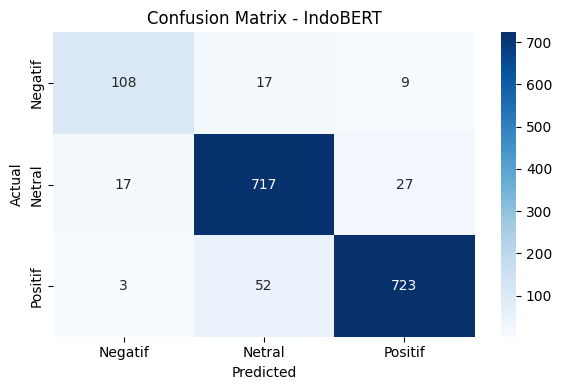

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_encoded, preds)
target_names = ['Negatif', 'Netral', 'Positif']

print("=== CONFUSION MATRIX ===")
print(cm)
print()

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - IndoBERT')
plt.tight_layout()
plt.show()

## 13. Menyimpan Model ke Google Drive

In [ ]:
MODEL_PATH = f'{DRIVE_PATH}/model_indobert_sentiment'
import os
os.makedirs(MODEL_PATH, exist_ok=True)

model.save_pretrained(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)
print(f"Model berhasil disimpan di: {MODEL_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan di: /content/drive/MyDrive/Skripsi_Faris/model_indobert_sentiment
